## Part 3 데이터 살펴보기

### 1-1 데이터프레임의 구조: 데이터 내용 미리보기

- 앞부분 보기: `DataFrame객체.head(n)` → 처음 n개 행
- 뒷부분 보기: `DataFrame객체.tail(n)` → 마지막 n개 행
    - n을 생략하면 기본값은 5

In [ ]:
# -*- coding: utf-8 -*-

import pandas as pd
from google.colab import files

# 1. 파일 직접 업로드 (실행 시 '파일 선택' 버튼이 나타납니다)
uploaded = files.upload()

# 2. read_csv() 함수로 df 생성 ('auto-mpg.csv' 파일 선택)
df = pd.read_csv('./auto-mpg.csv', header=None)

# 3. 열 이름 지정
df.columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
              'acceleration', 'model year', 'origin', 'name']

# 4. 데이터프레임 df의 내용 일부 확인
print(df.head())     # 처음 5개 행
print('\n')
print(df.tail())     # 마지막 5개 행

Saving auto-mpg.csv to auto-mpg.csv
    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0      130.0  3504.0          12.0          70   
1  15.0          8         350.0      165.0  3693.0          11.5          70   
2  18.0          8         318.0      150.0  3436.0          11.0          70   
3  16.0          8         304.0      150.0  3433.0          12.0          70   
4  17.0          8         302.0      140.0  3449.0          10.5          70   

   origin                       name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


      mpg  cylinders  displacement horsepower  weight  acceleration  \
393  27.0          4         140.0      86.00  2790.0          15.6   
394  44.0          4          97.0      52.00  2130.0          24.6   
395  32.0          4        

### 1-2 데이터 요약 정보 확인하기

**데이터프레임의 크기**

- `shape` 속성: 행과 열의 개수를 튜플 형태로 보여준다
- 데이터프레임 크기 확인: `DataFrame 객체.shape`

In [ ]:
# df의 모양과 크기 확인: (행의 개수, 열의 개수)를 투플로 반환
print(df.shape)

(398, 9)


**데이터프레임의 기본 정보**

- `info()` 메소드: 데이터프레임의 기본 정보를 화면에 출력
    - 클래스 유형
    - 행 인덱스 구성
    - 열 이름과 개수
    - 각 열의 자료형과 데이터 개수
    - 메모리 사용량
- 데이터프레임의 기본 정보 출력: `DataFrame 객체.info()`

In [ ]:
# 데이터프레임 df의 내용 확인
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB
None


In [ ]:
#<class 'pandas.core.frame.DataFrame'>     ← 클래스 유형
#RangeIndex: 398 entries, 0 to 397         ← 행 인덱스 0~397, 총 398개
#Data columns (total 9 columns):           ← 열 9개
#mpg           398 non-null float64        ← 열마다 결측 아닌 값의 개수와 자료형
#horsepower    398 non-null object         ← ⚠️ 숫자인데 object(문자열)!
#dtypes: float64(4), int64(3), object(2)   ← 실수형 4, 정수형 3, 문자열 2
#memory usage: 24.9+ KB
#None                                      ← 반환값 없음

**판다스 자료형**

| 판다스 자료형 | 파이썬 자료형 | 비고 |
| --- | --- | --- |
| int64 | int | 정수 |
| float64 | float | 실수(소수점 있는 수) |
| object | string | 문자열 |
| datetime64, timedelta64 | 없음 (datetime 라이브러리 활용) | 시간 데이터 |
- `dtypes` 속성으로 자료형만 따로 확인할 수 있다

In [ ]:
# 데이터프레임 df의 자료형 확인
print(df.dtypes)
print('\n')

# 시리즈(mpg 열)의 자료형 확인
print(df.mpg.dtypes)

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight          float64
acceleration    float64
model year        int64
origin            int64
name             object
dtype: object


float64


**데이터프레임의 기술 통계 정보 요약**

- `describe()` :숫자 데이터를 가진 열에 대해 주요 통계를 요약

| 항목 | 의미 |
| --- | --- |
| count | 데이터 개수 |
| mean | 평균 |
| std | 표준편차 |
| min / max | 최소값 / 최대값 |
| 25% / 50% / 75% | 사분위수 (50% = 중간값) |
- 숫자가 아닌 열까지 포함하려면 `include='all'` 옵션 추가
- 문자열에 맞는 통계 3개가 추가
    - `unique` : 서로 다른 값이 몇 종류인지
    - `top` : 가장 많이 나온 값
    - `freq` : top이 몇 번 나왔는지
    - 산술 데이터를 가진 열은 NaN 값이 표시된다

In [ ]:
# 데이터프레임 df의 기술 통계 정보 확인
print(df.describe())
print('\n')
print(df.describe(include='all'))

              mpg   cylinders  displacement       weight  acceleration  \
count  398.000000  398.000000    398.000000   398.000000    398.000000   
mean    23.514573    5.454774    193.425879  2970.424623     15.568090   
std      7.815984    1.701004    104.269838   846.841774      2.757689   
min      9.000000    3.000000     68.000000  1613.000000      8.000000   
25%     17.500000    4.000000    104.250000  2223.750000     13.825000   
50%     23.000000    4.000000    148.500000  2803.500000     15.500000   
75%     29.000000    8.000000    262.000000  3608.000000     17.175000   
max     46.600000    8.000000    455.000000  5140.000000     24.800000   

       model year      origin  
count  398.000000  398.000000  
mean    76.010050    1.572864  
std      3.697627    0.802055  
min     70.000000    1.000000  
25%     73.000000    1.000000  
50%     76.000000    1.000000  
75%     79.000000    2.000000  
max     82.000000    3.000000  


               mpg   cylinders  displacemen

### 1-3 데이터 개수 확인

**각 열의 데이터 개수**

- `count()`  메소드: 각 열의 데이터 개수를 시리즈 객체로 반환
    
    ↔`info()` 도 열마다 데이터 개수를 보여주지만 값을 돌려주지는 않는다
    
    - 유효한 값(NaN이 아닌 값)만 센다
- 열 데이터 개수 확인: `DataFrame 객체.count()`

In [ ]:
# -*- coding: utf-8 -*-

import pandas as pd

# read_csv() 함수로 df 생성
df = pd.read_csv('./auto-mpg.csv', header=None)

# 열 이름 지정
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name']

# 데이터프레임 df의 각 열이 가지고 있는 원소 개수 확인
print(df.count())
print('\n')

# df.count()가 반환하는 객체 타입 출력
print(type(df.count()))

mpg             398
cylinders       398
displacement    398
horsepower      398
weight          398
acceleration    398
model year      398
origin          398
name            398
dtype: int64


<class 'pandas.core.series.Series'>


**각 열의 고유값 개수**

- `value_counts()` 메소드:
    - 시리즈 객체의 고유값의 종류와 개수 확인
    - 고유값이 행 인덱스, 개수가 데이터 값이 되는 시리즈 객체 생성
    - `dropna` 옵션
        - `dropna=True` : NaN 값 제외해 계산
        - `dropna=False` : NaN 값 포함, 기본 옵션

In [ ]:
# 데이터프레임 df의 특정 열이 가지고 있는 고유값 확인
#origin(제조국) 열을 선택하고, 고유값별 개수를 세어 unique_values 변수에 저장
unique_values = df['origin'].value_counts()
print(unique_values)
print('\n')

# value_counts 메소드가 반환하는 객체 타입 출력
print(type(unique_values))

origin
1    249
3     79
2     70
Name: count, dtype: int64


<class 'pandas.core.series.Series'>


## 2. 통계 함수 적용

### 2-1 평균값

- `mean()` 메소드: 산술 데이터를 갖는 모든 열의 평균값을 각각 계산해 시리즈로 반환
- 모든 열의 평균: `DataFrame 객체.mean()`
- 특정 열의 평균: `DataFrame 객체['열 이름'].mean()`
- 최신 판다스에서는 문자열이 섞인 전체 데이터프레임 평균을 구할 때 `numeric_only=True` 옵션을 지정해야 에러가 발생하지 않는다

In [ ]:
# -*- coding: utf-8 -*-

import pandas as pd
from google.colab import files

# 1. 파일 직접 업로드 (실행 시 '파일 선택' 버튼이 나타납니다)
uploaded = files.upload()

# 2. read_csv() 함수로 df 생성
df = pd.read_csv('./auto-mpg.csv', header=None)

# 3. 열 이름 지정
df.columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
              'acceleration', 'model year', 'origin', 'name']

# 4. 평균값 계산
# 최신 판다스(2.0+)에서는 문자열('name' 등)이 섞인 전체 데이터프레임 평균을 구할 때
# numeric_only=True 옵션을 지정해야 에러(TypeError)가 발생하지 않는다
print(df.mean(numeric_only=True))
print('\n')
print(df['mpg'].mean())
print(df.mpg.mean())
print('\n')
# mpg와 weight 두 열을 골라 각각의 평균을 구한다
print(df[['mpg', 'weight']].mean())

Saving auto-mpg.csv to auto-mpg.csv
mpg               23.514573
cylinders          5.454774
displacement     193.425879
weight          2970.424623
acceleration      15.568090
model year        76.010050
origin             1.572864
dtype: float64


23.514572864321607
23.514572864321607


mpg         23.514573
weight    2970.424623
dtype: float64


### 2-2 중간값

- `median()` 메소드: 산술 데이터를 갖는 모든 열의 중간값을 각각 계산해 시리즈로 반환
- 모든 열의 중간값: `DataFrame 객체.median()`
- 특정 열의 중간값: `DataFrame 객체['열 이름'].median()`

In [4]:
# 중간값
print(df.mean(numeric_only=True))
print('\n')
print(df['mpg'].median())

mpg               23.514573
cylinders          5.454774
displacement     193.425879
weight          2970.424623
acceleration      15.568090
model year        76.010050
origin             1.572864
dtype: float64


23.0


### 2-3 최댓값

- `max()` 메소드: 데이터프레임의 각 열이 갖는 데이터 값 중 최대값을 계산해 시리즈로  반환
- 모든 열의 최대값: `DataFrame 객체.max()`
- 특정 열의 최대값: `DataFrame 객체['열 이름'].max()`

In [10]:
# 최대값
print(df.mean(numeric_only=True))
print('\n')
print(df['mpg'].max())
print(df['name'].max())
print(df['horsepower'].max())

mpg               23.514573
cylinders          5.454774
displacement     193.425879
weight          2970.424623
acceleration      15.568090
model year        76.010050
origin             1.572864
dtype: float64


46.6
vw rabbit custom
?


### 2-4 최솟값

- `min()` 메소드: 데이터프레임의 각 열이 갖는 데이터 값 중 최대값을 계산해 시리즈로  반환
- 모든 열의 최솟값: `DataFrame 객체.min()`
- 특정 열의 최솟값: `DataFrame 객체['열 이름'].min()`

In [11]:
# 최소값
print(df.min())
print('\n')
print(df['mpg'].min())

mpg                                 9.0
cylinders                             3
displacement                       68.0
horsepower                        100.0
weight                           1613.0
acceleration                        8.0
model year                           70
origin                                1
name            amc ambassador brougham
dtype: object


9.0


### 2-5 표준편차

- `std()` 메소드: 산술 데이터를 갖는 열의 표준편차를 계산해 시리즈로 반환
- 모든 열의 표준편차: `DataFrame 객체.std()`
- 특정 열의 표준편차: `DataFrame 객체['열 이름'].std()`
- 문자열을 갖는 열은 계산하지 않는다

In [13]:
# 표준편차
print(df.std(numeric_only=True))
print('\n')
print(df['mpg'].std())

mpg               7.815984
cylinders         1.701004
displacement    104.269838
weight          846.841774
acceleration      2.757689
model year        3.697627
origin            0.802055
dtype: float64


7.815984312565782


### 2-6 상관계수

- `corr()` 메소드: 두 열 간의 상관계수 계산
- 상관계수는 두 변수가 얼마나 함께 움직이는지를 -1에서 1 사이 숫자로 나타낸다

| 값 | 의미 | 예 |
| --- | --- | --- |
| 1에 가까움 | 한쪽이 커지면 다른 쪽도 커짐 (양의 상관) | 키 ↑ 몸무게 ↑ |
| 0에 가까움 | 별 관계 없음 |  |
| -1에 가까움 | 한쪽이 커지면 다른 쪽은 작아짐 (음의 상관) | 무게 ↑ 연비 ↓ |
- 모든 열의 상관계수: `DataFrame.corr()` → 숫자 열끼리 두 개씩 짝지어 모든 조합의 상관계수를 계산
- 특정 열의 상관계수: `DataFrame[열 이름의 리스트].corr()` → 상관계수는 열 두 개가 있어야 계산되므로, 반드시 리스트로 2개 이상 골라야 한다

In [15]:
# 상관계수
print(df.corr(numeric_only=True))
print('\n')
print(df[['mpg','weight']].corr())

                   mpg  cylinders  displacement    weight  acceleration  \
mpg           1.000000  -0.775396     -0.804203 -0.831741      0.420289   
cylinders    -0.775396   1.000000      0.950721  0.896017     -0.505419   
displacement -0.804203   0.950721      1.000000  0.932824     -0.543684   
weight       -0.831741   0.896017      0.932824  1.000000     -0.417457   
acceleration  0.420289  -0.505419     -0.543684 -0.417457      1.000000   
model year    0.579267  -0.348746     -0.370164 -0.306564      0.288137   
origin        0.563450  -0.562543     -0.609409 -0.581024      0.205873   

              model year    origin  
mpg             0.579267  0.563450  
cylinders      -0.348746 -0.562543  
displacement   -0.370164 -0.609409  
weight         -0.306564 -0.581024  
acceleration    0.288137  0.205873  
model year      1.000000  0.180662  
origin          0.180662  1.000000  


             mpg    weight
mpg     1.000000 -0.831741
weight -0.831741  1.000000


## 3. 판다스 내장 그래프 도구 활용

- 판다스는 Matplotlib 라이브러리 기능을 일부 내장하고 있어 import 하지 않고 그래프를 그릴 수 있다
- 시리즈, 데이터프레임 객체에 `plot()` 메소드를 적용해 그래프를 그린다
- `kind` 옵션: 그래프 종류 선택

| kind 옵션 | 그래프 | kind 옵션 | 그래프 |
| --- | --- | --- | --- |
| `'line'` | 선 그래프 (기본값) | `'kde'` | 커널 밀도 그래프 |
| `'bar'` | 수직 막대 그래프 | `'area'` | 면적 그래프 |
| `'barh'` | 수평 막대 그래프 | `'pie'` | 파이 그래프 |
| `'hist'` | 히스토그램 | `'scatter'` | 산점도 |
| `'box'` | 박스 플롯 | `'hexbin'` | 고밀도 산점도 |

---

### 3-1 선 그래프

- `plot()`에 아무 옵션도 주지 않으면 가장 기본인 선 그래프가 그려진다
- 선 그래프: `DataFrame 객체.plot()`
- `plot()` 메소드 전달하면 행 인덱스를 x축 데이터로 적용

Saving 남북한발전전력량.xlsx to 남북한발전전력량 (1).xlsx
       1991  1992  1993  1994  1995  1996  1997  1998  1999  2000  ...  2007  \
South  1186  1310  1444  1650  1847  2055  2244  2153  2393  2664  ...  4031   
North   263   247   221   231   230   213   193   170   186   194  ...   236   

       2008  2009  2010  2011  2012  2013  2014  2015  2016  
South  4224  4336  4747  4969  5096  5171  5220  5281  5404  
North   255   235   237   211   215   221   216   190   239  

[2 rows x 26 columns]




<Axes: >

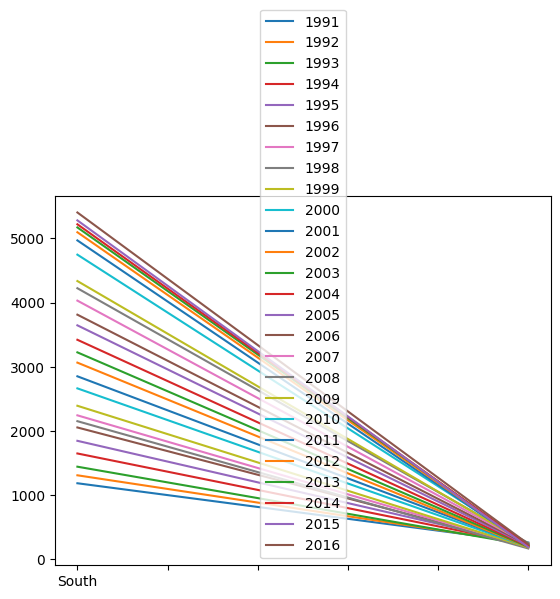

In [17]:
# -*- coding: utf-8 -*-

import pandas as pd
from google.colab import files

# 파일 직접 업로드 (실행 시 '파일 선택' 버튼이 나타난다)
uploaded = files.upload()

df = pd.read_excel('./남북한발전전력량.xlsx')   # 데이터프레임 변환

# 남한, 북한 발전량 합계 데이터만 추출
#iloc[행, 열]은 위치 번호로 고르는 방법, [0, 5]
#→ 0번 행(남한 합계)과 5번 행(북한 합계)만 고른다
#3: → 3번 열부터 끝까지 고른
df_ns = df.iloc[[0, 5], 3:]

#행 인덱스 0, 5를 'South', 'North'로 바꾼
df_ns.index = ['South','North']                # 행 인덱스 변경
df_ns.columns = df_ns.columns.map(int)         # 열 이름의 자료형을 정수형으로 변경
print(df_ns.head())
print('\n')

# 선 그래프 그리기
df_ns.plot()

     South North
1991  1186   263
1992  1310   247
1993  1444   221
1994  1650   231
1995  1847   230




<Axes: >

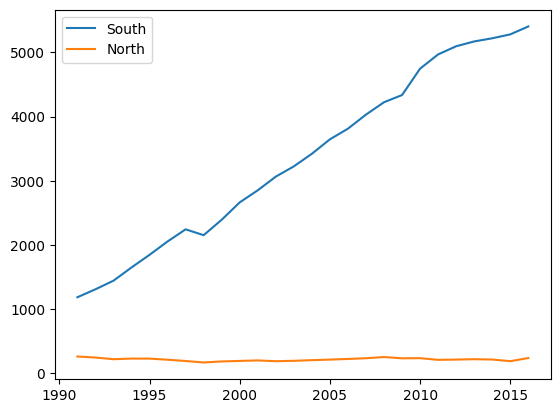

In [18]:
# 행, 열 전치하여 다시 그리기
#.T는 전치(Transpose)로, 행과 열을 뒤바꾼다
tdf_ns = df_ns.T
print(tdf_ns.head())
print('\n')
tdf_ns.plot()

### 3-2 막대 그래프

`DataFrame 객체.plot(kind='bar')`

</aside>

- `.T` : 행, 열을 전치

Saving 남북한발전전력량.xlsx to 남북한발전전력량 (2).xlsx
     South North
1991  1186   263
1992  1310   247
1993  1444   221
1994  1650   231
1995  1847   230




<Axes: >

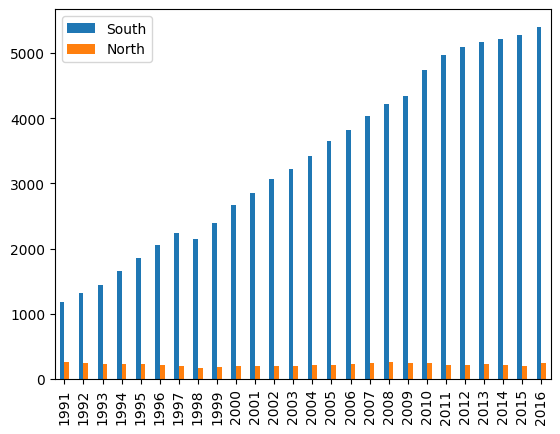

In [19]:
# -*- coding: utf-8 -*-

import pandas as pd
from google.colab import files

# 파일 직접 업로드 (실행 시 '파일 선택' 버튼이 나타난다)
uploaded = files.upload()

df = pd.read_excel('./남북한발전전력량.xlsx')   # 데이터프레임 변환

df_ns = df.iloc[[0, 5], 3:]                    # 남한, 북한 발전량 합계 데이터만 추출
df_ns.index = ['South','North']                # 행 인덱스 변경
df_ns.columns = df_ns.columns.map(int)         # 열 이름의 자료형을 정수형으로 변경

# 행, 열 전치하여 막대 그래프 그리기
tdf_ns = df_ns.T
print(tdf_ns.head())
print('\n')
tdf_ns.plot(kind='bar')

### 3-3 히스토그램

<aside>

`DataFrame 객체.plot(kind='hist')`

</aside>

|  | 막대 그래프 | 히스토그램 |
| --- | --- | --- |
| x축 | 항목 (연도) | 값의 구간 (발전량) |
| y축 | 그 항목의 값 (발전량) | 그 구간에 속하는 데이터 개수 (몇 개 연도인지) |

Saving 남북한발전전력량.xlsx to 남북한발전전력량 (6).xlsx


<Axes: ylabel='Frequency'>

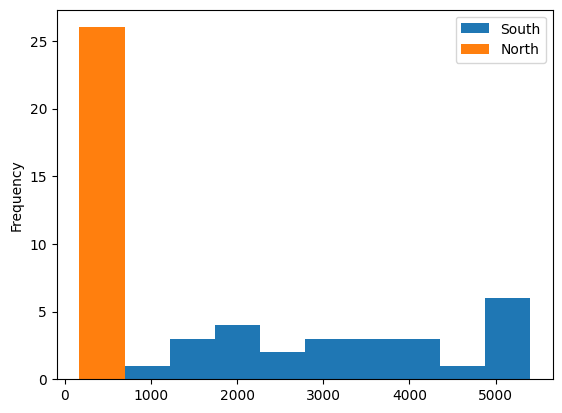

In [23]:
# -*- coding: utf-8 -*-

import pandas as pd
from google.colab import files

# 1. 파일 직접 업로드 (실행 시 '파일 선택' 버튼이 나타납니다)
uploaded = files.upload()

# 2. openpyxl 라이브러리를 통해 read_excel() 함수로 df 생성
df = pd.read_excel('./남북한발전전력량.xlsx')

# 3. 남한, 북한 발전량 합계 데이터만 추출 및 인덱스/열 처리
df_ns = df.iloc[[0, 5], 3:]                     # 남한, 북한 발전량 합계 데이터만 추출
df_ns.index = ['South', 'North']                # 행 인덱스 변경
df_ns.columns = df_ns.columns.map(int)          # 열 이름의 자료형을 정수형으로 변경

# ★ [핵심 추가] 문자열로 들어온 숫자를 실제 숫자형(float)으로 변환
# 결측치('-' 등)가 있어도 errors='coerce' 옵션으로 숫자로 안전하게 변환합니다.
df_ns = df_ns.apply(pd.to_numeric, errors='coerce')

# 4. 행, 열 전치하여 히스토그램 그리기
tdf_ns = df_ns.T
tdf_ns.plot(kind='hist')

### 3-4 산점도

<aside>

`DataFrame 객체.plot(x='열1', y='열2', kind='scatter')`

</aside>

- x축에 쓸 열과 y축에 쓸 열을 `x=`, `y=` 옵션으로 직접 지정해야 한다

Saving auto-mpg.csv to auto-mpg (1).csv


<Axes: xlabel='weight', ylabel='mpg'>

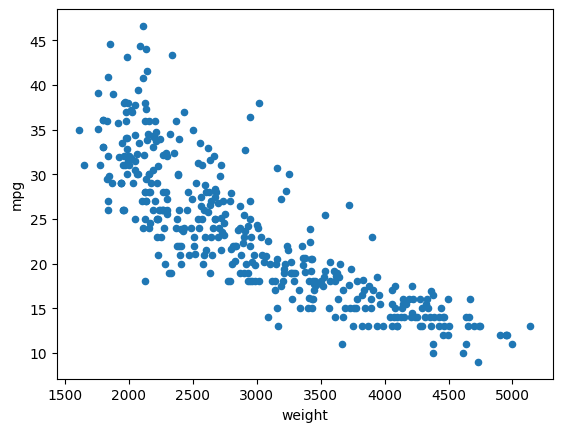

In [24]:
# -*- coding: utf-8 -*-

import pandas as pd
from google.colab import files

# 파일 직접 업로드 (실행 시 '파일 선택' 버튼이 나타난다)
uploaded = files.upload()

# read_csv() 함수로 df 생성
df = pd.read_csv('./auto-mpg.csv', header=None)

# 열 이름 지정
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name']

# 2개의 열을 선택하여 산점도 그리기
df.plot(x='weight', y='mpg', kind='scatter')

### 3-5 박스 플롯

<aside>

`DataFrame 객체.plot(kind='box')`

</aside>

- 박스 플롯: 특정 변수의 데이터 분포와 분산 정도에 대한 정보 제공
- 각 변수들의 데이터가 퍼져 있는 정도를 확인할 때 사용

Saving auto-mpg.csv to auto-mpg (2).csv


<Axes: >

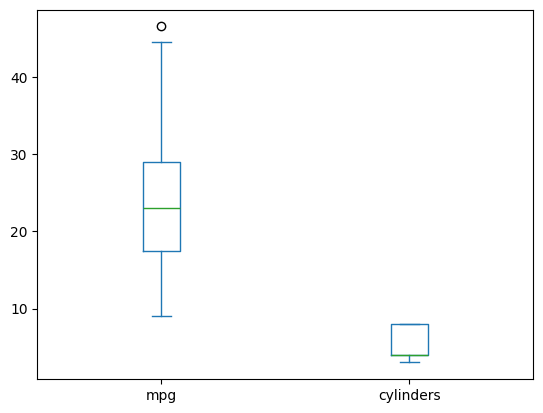

In [25]:
# -*- coding: utf-8 -*-

import pandas as pd
from google.colab import files

# 파일 직접 업로드 (실행 시 '파일 선택' 버튼이 나타난다)
uploaded = files.upload()

# read_csv() 함수로 df 생성
df = pd.read_csv('./auto-mpg.csv', header=None)

# 열 이름 지정
df.columns = ['mpg','cylinders','displacement','horsepower','weight',
              'acceleration','model year','origin','name']

# 열을 선택하여 박스 플롯 그리기
df[['mpg','cylinders']].plot(kind='box')